# Q8AnalyzeINF

Analyze the influenza reads in my Q8 sequence. I have two different known INFA hits in this sequencing run, S108 and S113. But barcoding has failed somehow and so I need to tease the sequences apart. This is complicated by the fact that the INFA genome comes in 8 segments and RespiCov contains an assortment of primers for it across different segments. 

Pre-analysis uzing czid suggests that both sequences are H1N1 so we're using that as the reference.

## Setup

In [8]:
%cd ../Q8/infa

/Users/rick/Lab/Q8/infa


In [18]:
%%bash
grep '^>' ref.fa
echo
cat primers.fa

>NC_026438.1 Influenza A virus (A/California/07/2009(H1N1)) segment 1 polymerase PB2 (PB2) gene, complete cds
>NC_026435.1 Influenza A virus (A/California/07/2009(H1N1)) segment 2 polymerase PB1 (PB1) gene, complete cds; and nonfunctional PB1-F2 protein (PB1-F2) gene, complete sequence
>NC_026437.1 Influenza A virus (A/California/07/2009(H1N1)) segment 3 polymerase PA (PA) gene, complete cds
>NC_026433.1 Influenza A virus (A/California/07/2009(H1N1)) segment 4 hemagglutinin (HA) gene, complete cds
>NC_026436.1 Influenza A virus (A/California/07/2009(H1N1)) segment 5 nucleocapsid protein (NP) gene, complete cds
>NC_026434.1 Influenza A virus (A/California/07/2009(H1N1)) segment 6 neuraminidase (NA) gene, complete cds
>NC_026431.1 Influenza A virus (A/California/07/2009(H1N1)) segment 7 matrix protein 2 (M2) and matrix protein 1 (M1) genes, complete cds
>NC_026432.1 Influenza A virus (A/California/07/2009(H1N1)) segment 8 nuclear export protein (NEP) and nonstructural protein 1 (NS1) gen

In [31]:
# Function to parse a UCLUST-like file
def parseUclust(input_file):
    clusters = {}
    cluster_order = []
    with open(input_file, 'r') as f:
        for line in f:
            columns = line.strip().split('\t')
            cluster_id = int(columns[1])
            if columns[0] == 'S':
                # Initialize a new cluster entry for a centroid record
                clusters[cluster_id] = {
                    'id': cluster_id,
                    'centroid': {
                        'length': int(columns[2]),
                        'readId': columns[8],
                    },
                    'hits': [],
                    'cluster_size': 0
                }
            elif columns[0] == 'H':
                # Append hit information to the corresponding cluster
                clusters[cluster_id]['hits'].append({
                    'length': int(columns[2]),
                    'similarity': columns[3],
                    'orientation': columns[4],
                    'readId': columns[8],
                })
            elif columns[0] == 'C':
                clusters[cluster_id]['cluster_size'] = int(columns[2])
                cluster_order.append(cluster_id)
    return (clusters, cluster_order)

First align all the primers to the INFA genome to create a BED file.

In [17]:
%%bash
seqkit locate -f primers.fa --bed --ignore-case --degenerate ref.fa > primers.bed
cat primers.bed

NC_026434.1	540	561	Influenza-A-virus-7	0	-
NC_026434.1	667	693	Influenza-A-virus-8	0	+
NC_026434.1	1194	1215	Influenza-A-virus-11	0	-
NC_026434.1	272	292	Influenza-A-virus-5	0	+
NC_026431.1	361	380	Influenza-A-virus-1	0	+
NC_026431.1	866	887	Influenza-A-virus-3	0	-


# Uncalssified barcode

Most INFA reads are in barcode17 and they worked fine. But the unclassified section seems to have a bunch of reads from both INFA samples. Let's try to separate that.

In [ ]:
%%bash

minimap2 -x map-ont -a ref.fa ../reads-sup/Q8-sup_unclassified.fastq.gz | \
    samtools view -b -F 4 | \
    samtools sort -o unc-INFA-H1N1.bam
samtools index unc-INFA-H1N1.bam

samtools flagstat unc-INFA-H1N1.bam

[M::mm_idx_gen::0.002*3.07] collected minimizers
[M::mm_idx_gen::0.005*1.70] sorted minimizers
[M::main::0.005*1.68] loaded/built the index for 8 target sequence(s)
[M::mm_mapopt_update::0.005*1.63] mid_occ = 10
[M::mm_idx_stat] kmer size: 15; skip: 10; is_hpc: 0; #seq: 8
[M::mm_idx_stat::0.005*1.58] distinct minimizers: 2391 (100.00% are singletons); average occurrences: 1.000; average spacing: 5.503; total length: 13158
[M::worker_pipeline::13.452*2.67] mapped 1318465 sequences
[M::worker_pipeline::17.697*2.64] mapped 1222167 sequences
[M::worker_pipeline::25.347*2.84] mapped 1382174 sequences
[M::worker_pipeline::25.936*2.79] mapped 756678 sequences
[M::main] Version: 2.30-r1287
[M::main] CMD: minimap2 -x map-ont -a ref.fa ../reads-sup/Q8-sup_unclassified.fastq.gz
[M::main] Real time: 25.939 sec; CPU: 72.256 sec; Peak RSS: 2.078 GB


43534 + 0 in total (QC-passed reads + QC-failed reads)
40862 + 0 primary
2 + 0 secondary
2670 + 0 supplementary
0 + 0 duplicates
0 + 0 primary duplicates
43534 + 0 mapped (100.00% : N/A)
40862 + 0 primary mapped (100.00% : N/A)
0 + 0 paired in sequencing
0 + 0 read1
0 + 0 read2
0 + 0 properly paired (N/A : N/A)
0 + 0 with itself and mate mapped
0 + 0 singletons (N/A : N/A)
0 + 0 with mate mapped to a different chr
0 + 0 with mate mapped to a different chr (mapQ>=5)


First split the bam into three regions, hard-trimming to remove the primers. 

In [27]:
%%bash

while read -r chrom start end name rest; do
  echo Processing "$name"
  printf "%s\t%s\t%s\t%s\n" "$chrom" "$start" "$end" "$name" > "$name.bed"
  # subset to the region
  samtools view -b -F 0x904 -L "$name.bed" unc-INFA-H1N1.bam -o "$name.raw.bam" 
  # hard-trim to the amplicon (drops primer overhangs) and keep only clipped reads
  samtools ampliconclip -b primers.bed --hard-clip --both-ends --strand --clipped -f ref.fa -o "$name.bam" "$name.raw.bam"
  samtools index "$name.bam"
  rm "$name.bed" "$name.raw.bam"
  echo wrote `samtools view -c "$name.bam"` reads to "$name.bam"
done < amplicons.bed


Processing seg6a


wrote 19638 reads to seg6a.bam
Processing seg6b
wrote 18338 reads to seg6b.bam
Processing seg7
wrote 2653 reads to seg7.bam


In [30]:
%%bash

rm -Rf clusters
mkdir clusters

samtools view -q 50 -b seg6a.bam | \
    samtools fasta - | \
    ../../vsearch-2.28.1-macos-aarch64/bin/vsearch --cluster_size - --id 0.70 \
        --centroids clusters/centroids.fasta \
        --uc clusters/clusters.uc \
        --consout clusters/consensus.fasta \
        --clusterout_sort --strand both


vsearch v2.28.1_macos_aarch64, 16.0GB RAM, 8 cores
https://github.com/torognes/vsearch

Reading file -[M::bam2fq_mainloop] discarded 0 singletons
[M::bam2fq_mainloop] processed 19104 reads
 100%
5056875 nt in 19104 seqs, min 61, max 6096, avg 265
Masking 100%
Sorting by abundance 100%
Counting k-mers 100%
Clustering 100%
Sorting clusters 100%
Writing clusters 100%
Clusters: 51 Size min 1, max 18730, avg 374.6
Singletons: 32, 0.2% of seqs, 62.7% of clusters
Multiple alignments 100%


In [32]:
(clusters, clusterIdsBySize) = parseUclust("clusters/clusters.uc")
print("Read %d clusters" % len(clusters))

Read 51 clusters


Largest cluster sizes: [18730, 169, 81, 15, 11, 11, 10, 8, 7, 6]


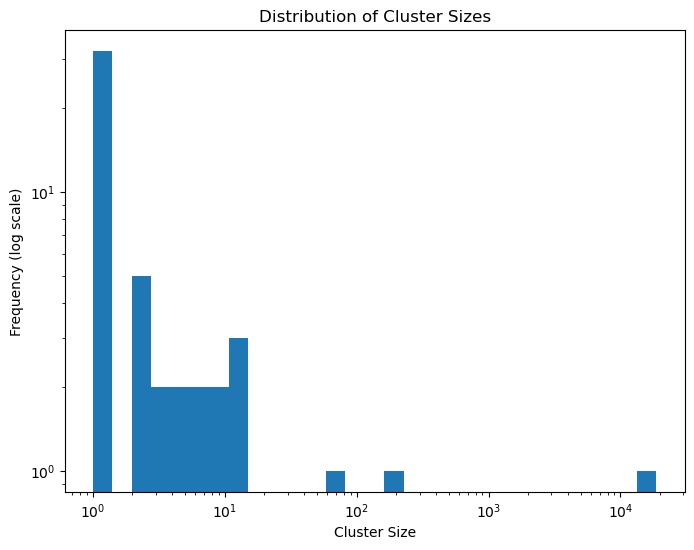

In [33]:
import numpy as np

import matplotlib.pyplot as plt

print("Largest cluster sizes:", [clusters[c]['cluster_size'] for c in clusterIdsBySize[:10]])

cluster_sizes = [c['cluster_size'] for c in clusters.values()]

plt.figure(figsize=(8, 6))
plt.hist(cluster_sizes, bins=np.logspace(np.log10(1), np.log10(max(cluster_sizes)), 30), log=True)
plt.xscale('log')
plt.xlabel('Cluster Size')
plt.ylabel('Frequency (log scale)')
plt.title('Distribution of Cluster Sizes')
plt.show()